### Autograd Practice

In [2]:
import torch

In [ ]:
# example 1.1 Simple Scalar Derivatives
x=torch.tensor(4.0,requires_grad=True)
y=x**2
y.backward() #computes gradients via chain rule
print(f"dy/dx for x =3: {x.grad}")

dy/dx for x =3: 8.0


In [ ]:
# Mutli-variable function
# z=x^2 + y^3
x=torch.tensor(2.0,requires_grad=True)
y=torch.tensor(3.0,requires_grad=True)
z=x**2 + y**3
z.backward()
print(f"dz/dx={x.grad}")

dz/dx=4.0


### Some Important Concepts **bold text**

##### Important Terminologies to Understand

Technical Explanation

- Leaf tensors have is_leaf = True

- Non-leaf tensors are intermediate results in computational graph

- PyTorch only stores gradients in leaf tensors to save memory

In [ ]:
#Leaf and non-Leaf tensors
#pytorch only stores gradients in leaf tensors to save memory

x=torch.randn(2,3 , requires_grad=True)
# this above is a Leaf tensor

y=torch.randn(2,3, requires_grad=False) # y is not a leaf tensor by default

z=x**2 #Non- Leaf tensor - Result of an operation
w=y+1 #Non- Leaf tensor - Result of Operation

loss= z.sum() + w.sum() # Summing z and w.sum() to make loss a scalar
loss.backward()

print(f"x.grad: {x.grad}") # has gradient
print(f"w.grad: {w.grad}") #None - non-leaf tensor (unless requires_grad=True is set for y)

x.grad: tensor([[ 0.1933,  0.0210, -2.5634],
        [ 2.7312, -1.4274, -0.6056]])
w.grad: None


#### Getting Non-Leaf Gradients (Wheen Needed)

In [ ]:
x=torch.tensor(3.0,requires_grad=True)
z=x**2

#Method 1 : Use retain_grad()
z.retain_grad() #tell pytorch to keep this gradients
loss=z*2
loss.backward()

print(f"x.grad: {x.grad}")
print(f"z.grad: {z.grad}")

#method 2 use hooks (advanced)





x.grad: 12.0
z.grad: 2.0


##### Backward() can only Be called on Scaler Tensors

In [ ]:
x=torch.tensor([1.0,2.0,3.0],requires_grad=True)
y=x.sum()
print(f"shape of y : {y.shape}")
y.backward()
print(f"x.grad: {x.grad}")

shape of y : torch.Size([])
x.grad: tensor([1., 1., 1.])


In [ ]:
#Error - Non-scalar tensor
x.grad.zero_()
z=x**2
print(f"z.shape: {z.shape}")
#z.backward() #will give error

z.shape: torch.Size([3])


In [ ]:
# Solution 1 - convert to scaler
x.grad.zero_()
z=x**2
loss=z.sum()
loss.backward()
print(f"x.grad: {x.grad}")


x.grad: tensor([ 0.5792,  1.6810, -1.3993, -0.5574])


##### Gradient Accumlate by default
Accumulation: New gradients are added to existing gradients instead of replacing them
Technical Explanation

- Each backward() call adds gradients to .grad attribute
- Useful for gradient accumulation across mini-batches
- Must manually reset gradients between parameter updates

In [ ]:
x=torch.tensor(2.0,requires_grad=True)
y1=x**2
y1.backward()
print(f"x.grad: {x.grad}")


#second backward pass accumlates
y2=x**3
y2.backward() #dy/dx=3x^2=12
print(f"x.grad: {x.grad}")

#Third backward pass
y3=x+5
y3.backward()
print(f"x.grad: {x.grad}")

x.grad: 4.0
x.grad: 16.0
x.grad: 17.0


#### Vector and Matrix Gradients

In [ ]:
#Vector Operations
x=torch.tensor([1.0,2.0,3.0],requires_grad=True)
y=torch.norm(x) #L2 norm
y.backward()

print(f"y grad : {x.grad}")

y grad : tensor([0.2673, 0.5345, 0.8018])


In [ ]:
# Matrix Operations
A=torch.randn(3,4,requires_grad=True)
x=torch.randn(4,requires_grad=True)
y=torch.mv(A,x)  #torch.mv(A,x) Matrix-vector Product
loss=y.sum()

#A.retain_grad() # Retain gradients for A

loss.backward()

print(f"A.grad shape: {A.grad.shape}")
print(f"x.grad shape: {x.grad.shape}")

A.grad shape: torch.Size([3, 4])
x.grad shape: torch.Size([4])


#### 1 *Autograd*  basic examples

In [ ]:
import torch
x=torch.tensor([2.0,3.0],requires_grad=True)
y=(x[0]**2) + 3*(x[1]**2)
y.backward()
print("Gradient :",  x.grad)

Gradient : tensor([ 4., 18.])


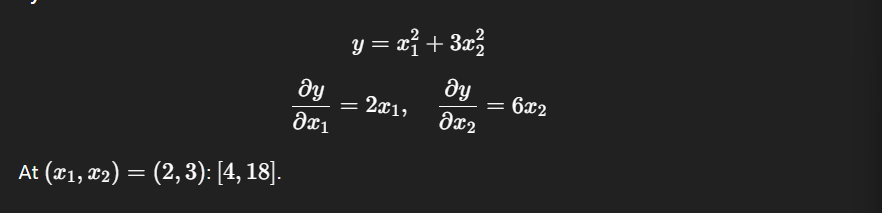

In [ ]:
x=torch.tensor([1.0,2.0],requires_grad=True)
y=torch.sin(x[0]+x[0]*x[1])
y.backward()
print("Gradient: ",x.grad)

Gradient:  tensor([-2.9700, -0.9900])


In [ ]:
# Log + square sum
x=torch.tensor([1.0,2.0,4.0],requires_grad=True)
y=torch.log(torch.sum(x**2))
y.backward()
print("Gradient :",x.grad )

Gradient : tensor([0.0952, 0.1905, 0.3810])


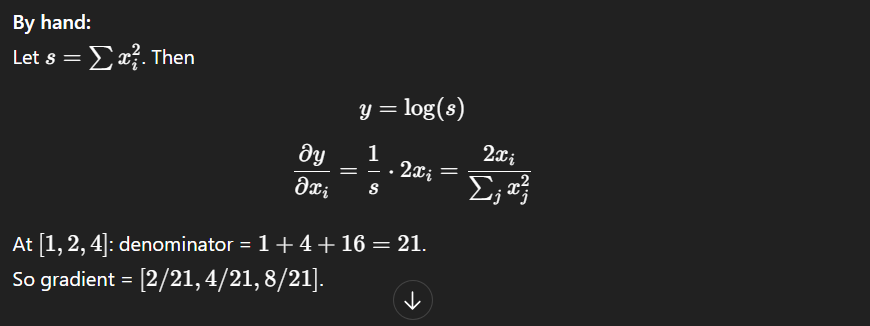

In [ ]:
# Vector norm Squared
x=torch.tensor([1.0,-1.0,2.0],requires_grad=True)
y=torch.sum(x**2) # Squared L2 Norm
y.backward()
print("grad : ",x.grad)

grad :  tensor([ 2., -2.,  4.])


In [ ]:
#Nonlinear Combination
x=torch.tensor([2.0,1.0],requires_grad=True)
y=torch.exp(x[0]*x[1]) + torch.cos(x[1])
y.backward()
print("gradient:",x.grad)

gradient: tensor([ 7.3891, 13.9366])


##### Simple Linear Layer

In [6]:
def linear_forward(x,W,b):
    return torch.mm(x,W.t())+b

batch_size,input_dim,output_dim=2,3,4
x=torch.randn(batch_size,input_dim,requires_grad=True)
W=torch.randn(output_dim,input_dim,requires_grad=True)
b=torch.randn(output_dim,requires_grad=True)

output=linear_forward(x,W,b)
loss=output.sum()
loss.backward()

print(W.grad.shape)
print(b.grad.shape)

torch.Size([4, 3])
torch.Size([4])


In [7]:
## Activation Function Gradient
x=torch.tensor([-1.0,0.0,1.0,2.0],requires_grad=True)
y=torch.relu(x)
loss=y.sum()
loss.backward()

